In [1]:
import numpy as np
from matplotlib import pyplot as plt
import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd # Pour un affichage propre du tableau
from datetime import datetime

# --- 1. Définition de l'Architecture (Obligatoire avant chargement) ---
class MVDR_FFNN(nn.Module):
    def __init__(self):
        super(MVDR_FFNN, self).__init__()
        self.layer1 = nn.Linear(3, 512)
        self.layer2 = nn.Linear(512, 512)
        self.layer3 = nn.Linear(512, 1024)
        self.layer4 = nn.Linear(1024, 512)
        self.layer5 = nn.Linear(512, 32) # Dernière couche 
        
    def forward(self, x):
        # 1. Les L-1 premières couches cachées utilisent Tanh ou leaky_relu  x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer1(x), 0.1)
        x = F.leaky_relu(self.layer2(x), 0.1)
        x = F.leaky_relu(self.layer3(x), 0.1)
        x = F.leaky_relu(self.layer4(x), 0.1)
               
        x = self.layer5(x)        
        return x

# --- 2. Configuration du Device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 3. Initialisation et Chargement Dynamique ---
model = MVDR_FFNN().to(device)

# On définit le dossier de recherche
checkpoint_dir = "../models_FFNN"
search_pattern = os.path.join(checkpoint_dir, "*.pth")
list_of_files = glob.glob(search_pattern)

if not list_of_files:
    raise FileNotFoundError(f"⚠️ Aucun fichier .pth trouvé dans {checkpoint_dir}")

# Sélection du fichier le plus récent (basé sur le temps de création)
latest_model_path = max(list_of_files, key=os.path.getctime)

# Chargement des poids
# map_location=device permet de basculer de GPU à CPU sans erreur
checkpoint = torch.load(latest_model_path, map_location=device, weights_only=True)
model.load_state_dict(checkpoint)

# --- 4. Mise en mode Évaluation ---
model.eval()

print("-" * 50)
print(f"✅ MODÈLE CHARGÉ : {os.path.basename(latest_model_path)}")
print(f"📍 CHEMIN : {latest_model_path}")
print(f"💻 DEVICE : {device}")
print("-" * 50)

--------------------------------------------------
✅ MODÈLE CHARGÉ : MVDR_FFNN20260331_1650_model.pth
📍 CHEMIN : ../models_FFNN/MVDR_FFNN20260331_1650_model.pth
💻 DEVICE : cuda
--------------------------------------------------


In [2]:
# --- Importation de ta fonction MVDR (Assure-toi que MVDR.py est au bon endroit) ---
from MVDR import mvdr_results 

# =============================================================================
# --- PARAMÈTRES ET CONFIGURATION ---
# =============================================================================
Nr = 16
d = 0.5
K = 10000
sample_rate = 1e6
t = np.arange(K)/sample_rate

# Puissances
P_soi = 1
P_int1 = 0.5
P_int2 = 1
P_noise = 0.03

# Scans d'angles
theta_scan = np.linspace(-np.pi/2, np.pi/2, 1000)
theta_scan_deg = np.rad2deg(theta_scan)
angles_scan_NN = np.linspace(-90, 90, 1000)

# =============================================================================
# --- FONCTIONS UTILITAIRES ---
# =============================================================================

def get_steering_vector(theta_deg, Nr=16, d=0.5):
    theta_rad = np.deg2rad(theta_deg)
    n = np.arange(Nr)
    return np.exp(2j * np.pi * d * n * np.sin(theta_rad))

def get_gain_at_angle(angle_cible, angles_scan, gains_db):
    idx_proche = np.argmin(np.abs(angles_scan - angle_cible))
    return gains_db[idx_proche]

def generate_random_test_data(n=105, min_sep=5.0):
    triads = []
    while len(triads) < n:
        soi, soa1, soa2 = np.random.uniform(-60, 60, 3)
        if (abs(soi-soa1) >= min_sep and abs(soi-soa2) >= min_sep and abs(soa1-soa2) >= min_sep):
            triads.append([soi, soa1, soa2])
    return np.array(triads)

# =============================================================================
# --- BOUCLE PRINCIPALE DE TEST (105 TRIADES) ---
# =============================================================================
test_triads = generate_random_test_data(105)
log_data = []  
all_weights = [] # Pour stocker les poids complexes pour le tracé final
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

print(f"🚀 Analyse de {len(test_triads)} triades en cours...")

for idx in range(len(test_triads)):
    soi_test, soa1_test, soa2_test = test_triads[idx]
    
    # --- 1. PRÉDICTION NN ---
    with torch.no_grad():
        entree = torch.tensor([[soi_test, soa1_test, soa2_test]], dtype=torch.float32).to(device) / 60.0
        sortie = model(entree).detach().cpu().numpy().flatten()
    
    # Normalisation et reconstruction du vecteur complexe
    norme_ia = np.linalg.norm(sortie)
    sortie_norm = sortie / (norme_ia + 1e-12)
    w_complex = sortie_norm[:16] + 1j * sortie_norm[16:]
    
    # --- 2. CALCUL MVDR (via ton fichier externe) ---
    # Récupère le vecteur de poids optimal et le SINR théorique
    w_tr, sinr_mv = mvdr_results(soi_test, soa1_test, soa2_test)
    w_tr = w_tr.flatten()

    # --- 3. GÉNÉRATION DES SIGNAUX POUR LE CALCUL DU SINR NN ---
    a1 = get_steering_vector(soi_test).reshape(-1,1)
    a2 = get_steering_vector(soa1_test).reshape(-1,1)
    a3 = get_steering_vector(soa2_test).reshape(-1,1)
    
    soi = a1 @ (np.sqrt(P_soi) * np.exp(2j*np.pi*0.01e6*t).reshape(1,-1))
    int1 = a2 @ (np.sqrt(P_int1) * np.exp(2j*np.pi*0.02e6*t).reshape(1,-1))
    int2 = a3 @ (np.sqrt(P_int2) * np.exp(2j*np.pi*0.03e6*t).reshape(1,-1))
    noise = (np.random.randn(Nr,K) + 1j*np.random.randn(Nr,K)) / np.sqrt(2) * np.sqrt(P_noise)
    
    # --- 4. CALCUL DU SINR SORTIE NN ---
    y_soi_nn = w_complex.conj().T @ soi
    y_int_noise_nn = w_complex.conj().T @ (int1 + int2 + noise)
    
    P_soi_out_nn = np.mean(np.abs(y_soi_nn)**2)
    P_int_noise_out_nn = np.mean(np.abs(y_int_noise_nn)**2)
    SINR_out_nn_dB = 10 * np.log10(P_soi_out_nn / (P_int_noise_out_nn + 1e-12))

    # --- 5. CALCUL DES DIAGRAMMES (POUR EXTRAIRE LES GAINS DU LOG) ---
    # Diagramme NN
    p_nn = np.array([np.abs(np.vdot(w_complex, get_steering_vector(ang)))**2 for ang in angles_scan_NN])
    gain_db_NN = 10 * np.log10(p_nn / p_nn[np.argmin(np.abs(angles_scan_NN - soi_test))] + 1e-12)
    
    # Diagramme MVDR
    p_mv = np.array([np.abs(np.vdot(w_tr, get_steering_vector(ang)))**2 for ang in theta_scan_deg])
    results_mvdr = 10 * np.log10(p_mv / p_mv[np.argmin(np.abs(theta_scan_deg - soi_test))] + 1e-12)

    # --- 6. REMPLISSAGE DU LOG ---
    g_mvdr_soi = get_gain_at_angle(soi_test, theta_scan_deg, results_mvdr)
    g_nn_soi    = get_gain_at_angle(soi_test, angles_scan_NN, gain_db_NN)
    g_mvdr_soa1 = get_gain_at_angle(soa1_test, theta_scan_deg, results_mvdr)
    g_nn_soa1   = get_gain_at_angle(soa1_test, angles_scan_NN, gain_db_NN)
    g_mvdr_soa2 = get_gain_at_angle(soa2_test, theta_scan_deg, results_mvdr)
    g_nn_soa2   = get_gain_at_angle(soa2_test, angles_scan_NN, gain_db_NN)

    # --- REMPLISSAGE DU LOG (Correction des colonnes) ---
    log_data.append({
        'ID': idx + 1,
        'SOI': soi_test, 'SOA1': soa1_test, 'SOA2': soa2_test,
        'MV_SOI': g_mvdr_soi,   # On met le GAIN, pas l'angle
        'NN_SOI': g_nn_soi,
        'MV_SOA1': g_mvdr_soa1,
        'NN_SOA1': g_nn_soa1,
        'MV_SOA2': g_mvdr_soa2,
        'NN_SOA2': g_nn_soa2,
        'Dt_MV_NN_SOI': abs(g_mvdr_soi - g_nn_soi),
        'Dt_MV_NN_SOA1': abs(g_mvdr_soa1 - g_nn_soa1),
        'Dt_MV_NN_SOA2': abs(g_mvdr_soa2 - g_nn_soa2)
    })
    
    # --- STOCKAGE DES POIDS ---
    # On stocke les poids complexes sous forme de dictionnaire pour chaque triade
    all_weights.append({
        'w_nn': w_complex,       # Vecteur 16 elements complexes
        'w_mvdr': w_tr.flatten() # Vecteur 16 elements complexes
    })

print(f"SINR sortie MVDR (dB) = {sinr_mv:.2f}")
print(f"SINR sortie NN (dB) = {SINR_out_nn_dB:.2f}")
# --- SAUVEGARDE ET AFFICHAGE CSV ---
df_log = pd.DataFrame(log_data).round(2)
csv_path = f"../FFNN_tests/Test_105_triad_{timestamp}.csv"
df_log.to_csv(csv_path, index=False, sep=';')

print(f"✅ CSV sauvegardé : {csv_path}")
print(df_log.head(20).to_string(index=False))

# =====================================================================================================================================


🚀 Analyse de 105 triades en cours...
SINR sortie MVDR (dB) = 27.22
SINR sortie NN (dB) = 27.24
✅ CSV sauvegardé : ../FFNN_tests/Test_105_triad_20260331_1652.csv
 ID    SOI   SOA1   SOA2  MV_SOI  NN_SOI  MV_SOA1  NN_SOA1  MV_SOA2  NN_SOA2  Dt_MV_NN_SOI  Dt_MV_NN_SOA1  Dt_MV_NN_SOA2
  1 -31.48   7.21  41.37     0.0     0.0   -53.05   -47.21   -69.55   -47.35           0.0           5.84          22.21
  2 -13.60 -25.54 -46.68     0.0     0.0   -54.66   -39.71   -50.88   -35.50           0.0          14.95          15.38
  3 -57.72  58.59 -45.31     0.0     0.0   -76.50   -40.38   -77.32   -28.99           0.0          36.12          48.33
  4   7.02  -1.60 -17.69     0.0     0.0   -47.12   -37.30   -61.84   -38.46           0.0           9.82          23.38
  5 -44.06 -20.70  22.36     0.0     0.0   -52.74   -44.98   -70.25   -42.28           0.0           7.76          27.97
  6 -28.60 -43.46 -55.62     0.0     0.0   -60.05   -31.86   -57.53   -40.65           0.0          28.19        

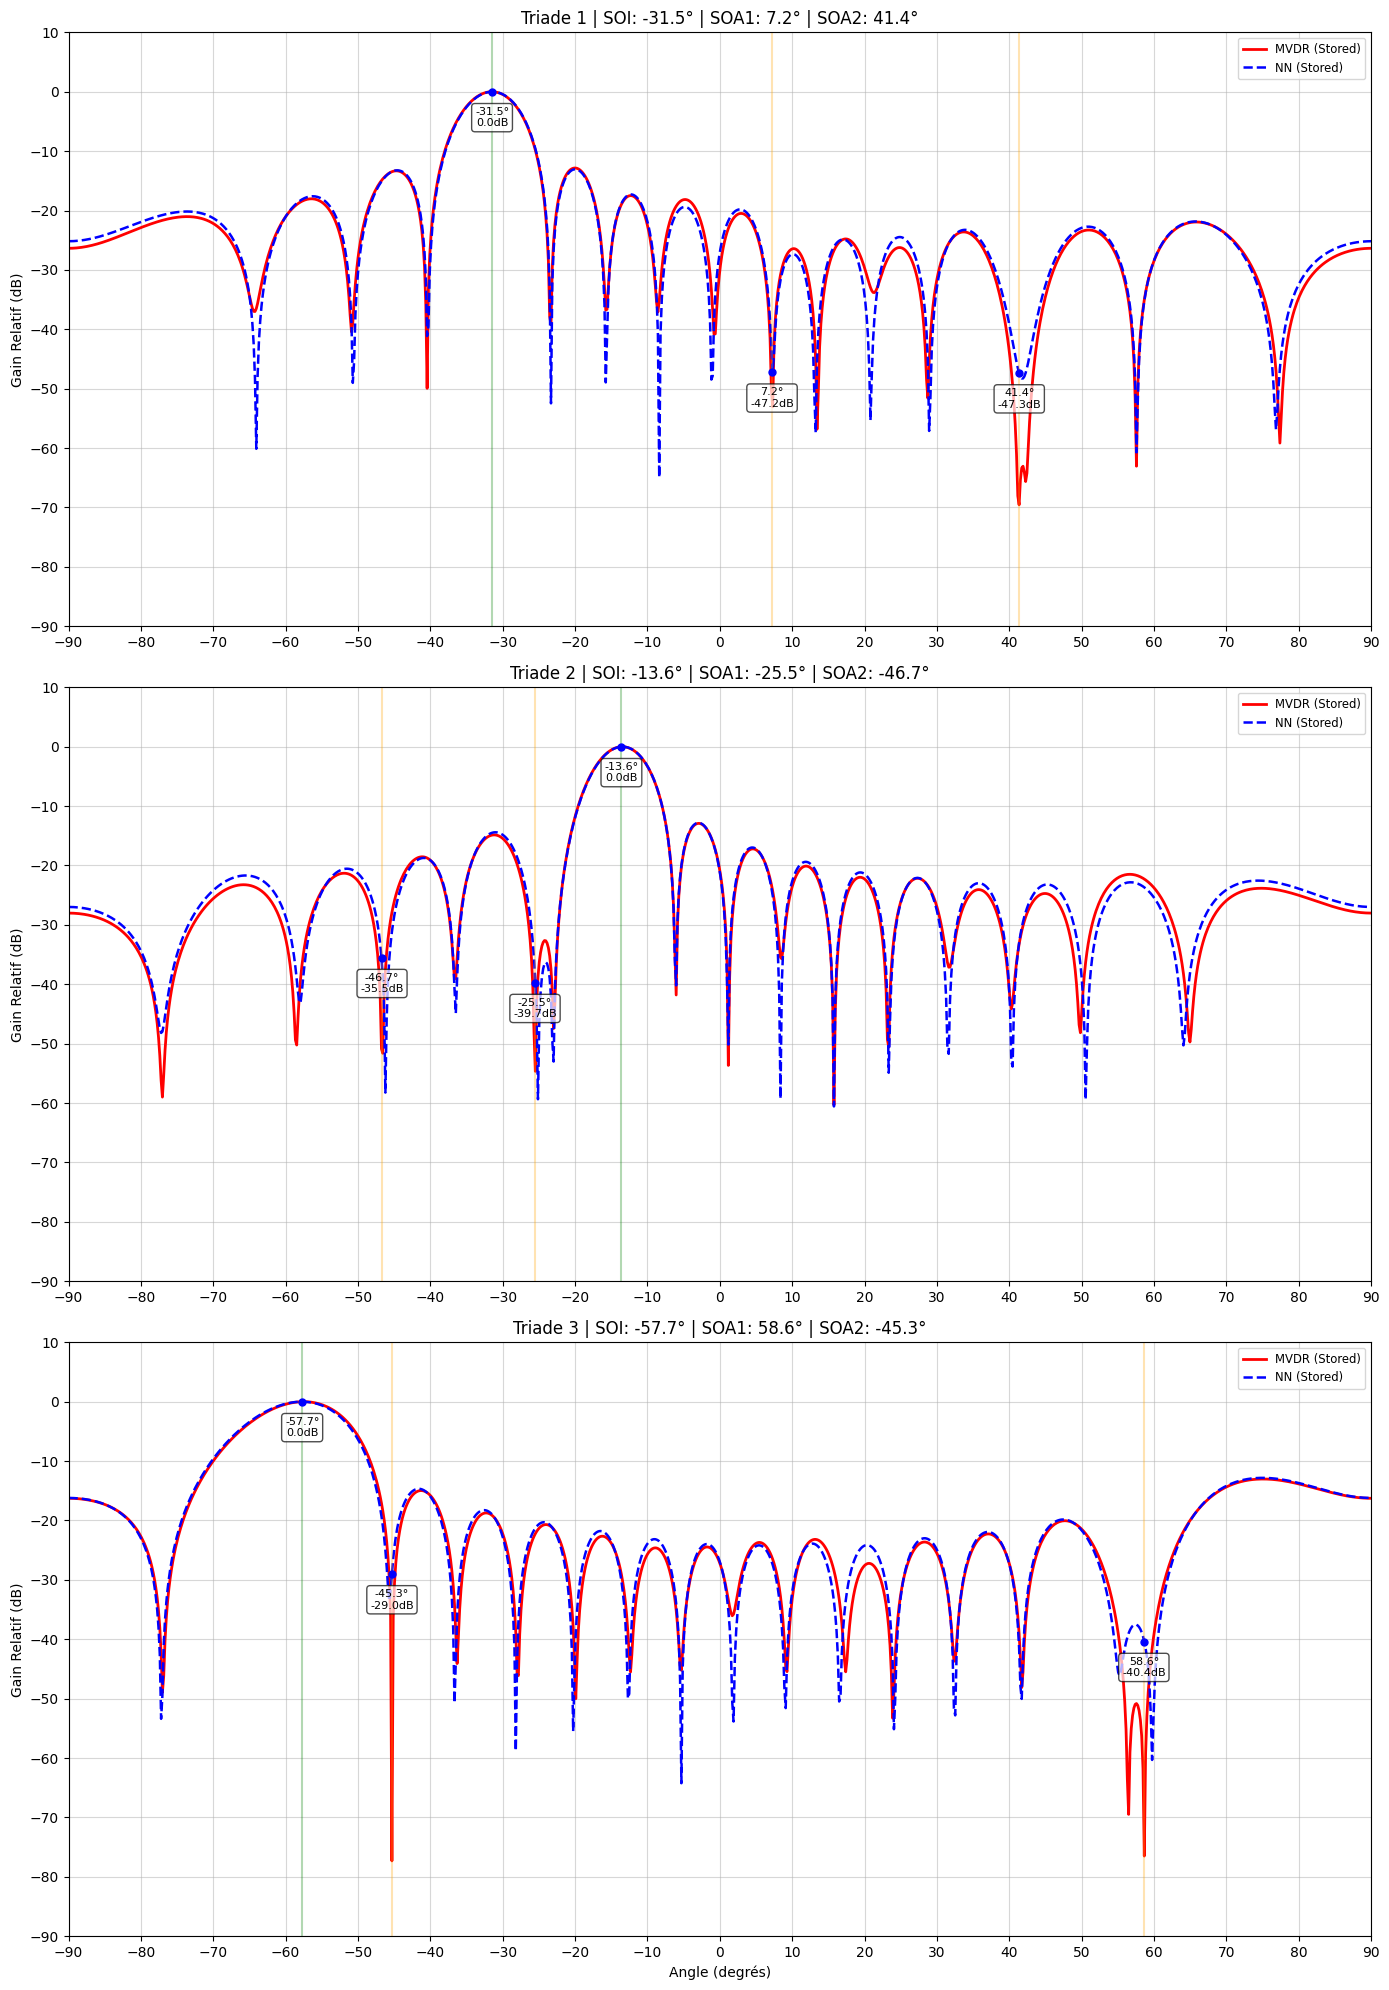

In [4]:
# =====================================================================================================================================
# --- AFFICHAGE DES DIAGRAMMES À PARTIR DES POIDS STOCKÉS ---
# =====================================================================================================================================

indices_plot = [0, 1, 2] 
fig, axs = plt.subplots(3, 1, figsize=(14, 20))

for i, idx in enumerate(indices_plot):
    soi_t, soa1_t, soa2_t = test_triads[idx]
    ax = axs[i]

    # RÉCUPÉRATION DES POIDS DÉJÀ CALCULÉS
    w_nn_c = all_weights[idx]['w_nn']
    w_mv_c = all_weights[idx]['w_mvdr']

    # --- SCAN NN (Réutilisation) ---
    p_nn = np.array([np.abs(np.vdot(w_nn_c, get_steering_vector(ang)))**2 for ang in angles_scan_NN])
    ref_nn = np.abs(np.vdot(w_nn_c, get_steering_vector(soi_t)))**2
    db_nn_plot = 10 * np.log10(p_nn / ref_nn + 1e-12)

    # --- SCAN MVDR (Réutilisation) ---
    p_mv = np.array([np.abs(np.vdot(w_mv_c, get_steering_vector(ang)))**2 for ang in theta_scan_deg])
    ref_mv = np.abs(np.vdot(w_mv_c, get_steering_vector(soi_t)))**2
    db_mv_plot = 10 * np.log10(p_mv / ref_mv + 1e-12)

    # --- AFFICHAGE ---
    ax.plot(theta_scan_deg, db_mv_plot, color='red', label='MVDR (Stored)', linewidth=2)
    ax.plot(angles_scan_NN, db_nn_plot, color='blue', linestyle='--', label='NN (Stored)', linewidth=1.8)

    # Annotations (SOI, SOA1, SOA2)
    triad = [soi_t, soa1_t, soa2_t]
    for j, ang in enumerate(triad):
        g_mv = get_gain_at_angle(ang, theta_scan_deg, db_mv_plot)
        g_nn = get_gain_at_angle(ang, angles_scan_NN, db_nn_plot)
        
        ax.axvline(ang, color=['green','orange','orange'][j], alpha=0.3)
        ax.plot(ang, g_nn, 'bo', markersize=5)
        ax.annotate(f"{ang:.1f}°\n{g_nn:.1f}dB", (ang, g_nn), xytext=(0, -25), 
                     textcoords="offset points", ha='center', fontsize=8, 
                     bbox=dict(boxstyle='round', fc='white', alpha=0.7))

    # Mise en forme
    ax.set_title(f"Triade {idx+1} | SOI: {soi_t:.1f}° | SOA1: {soa1_t:.1f}° | SOA2: {soa2_t:.1f}°", fontsize=12)
    ax.set_ylabel("Gain Relatif (dB)")
    ax.set_ylim([-90, 5])
    ax.set_yticks(range(-90, 11, 10))
    ax.grid(True, linestyle='-', alpha=0.5)
    ax.set_xlim([-90, 90])
    ax.set_xticks(range(-90, 91, 10))
    ax.legend(loc='upper right', fontsize='small')

plt.xlabel("Angle (degrés)")
plt.tight_layout()
plt.show()